# **Linearity Assumption tests**
- Linearity
- Residual Exepetions (E(e) = 0 )
- Homoscadestacity
- Auto-correlation
- Normality 

#### **Load Libraries**

In [13]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_rainbow
from statsmodels.graphics.regressionplots import plot_ccpr
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings# Ignore all warnings
warnings.filterwarnings('ignore')

#### **Load data**

In [14]:
houseing_df = pd.read_csv("data/Housing.csv")

In [15]:
houseing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#### **Data preparation**

In [16]:
def encodeColumns(df, columns, dataType, column=""):
    if dataType == "Binary":
        for col in columns:
            df[col] = df[col].map({'yes':1, 'no':0})
    else:
        df =  pd.get_dummies(df, columns=[column], drop_first=True) 
    return df



##### **Data Encoding**

In [17]:
binary_column_names =[
    'mainroad',	'guestroom', 'basement',	'hotwaterheating',	'airconditioning',	'prefarea'
] 

#  ordinal
df = encodeColumns(df = houseing_df, columns=[], column="furnishingstatus", dataType="Ordinal")
df.head() 

# binary
df = encodeColumns(df = df, columns =binary_column_names, dataType ="Binary")
 

**Confirming our data has been encoded**

In [18]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


**Checking for null values**

In [19]:
df.isna().sum() / len(df) * 100

price                              0.0
area                               0.0
bedrooms                           0.0
bathrooms                          0.0
stories                            0.0
mainroad                           0.0
guestroom                          0.0
basement                           0.0
hotwaterheating                    0.0
airconditioning                    0.0
parking                            0.0
prefarea                           0.0
furnishingstatus_semi-furnished    0.0
furnishingstatus_unfurnished       0.0
dtype: float64

##### **Preparing for ML**
Kindly note for this we will be using [statsmodels](https://www.statsmodels.org/stable/) as it specifically built for statistical inferences and is good in checking assumptions such as linearity(current case)

In [20]:
# Separate target and predictors
y = df['price']
X = df.drop('price', axis=1)

##### **Add constant for intercept**
the intercept allows the regression line to not be forced through the origin (0,0). In real-world data (like house prices), even a zero‑area house would nott sell for $0. The intercept captures that baseline value

In [21]:
X_sm = sm.add_constant(X)

In [31]:
display(X_sm.dtypes)
display(X_sm.head())

const                              float64
area                                 int64
bedrooms                             int64
bathrooms                            int64
stories                              int64
mainroad                             int64
guestroom                            int64
basement                             int64
hotwaterheating                      int64
airconditioning                      int64
parking                              int64
prefarea                             int64
furnishingstatus_semi-furnished      int64
furnishingstatus_unfurnished         int64
dtype: object

,const,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,1.0,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,1.0,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,1.0,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,1.0,7420,4,1,2,1,1,1,0,1,2,0,0,0


##### **convert the boolean dtype to numbers:**

In [32]:
bool_cols = X_sm.select_dtypes(include='bool').columns
X_sm[bool_cols] = X_sm[bool_cols].astype(int)

In [36]:
model = sm.OLS(y, X_sm).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          9.07e-123
Time:                        15:22:50   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
area                              244.1394     24.289     10.052      0.000     196.425     291.853
bedrooms                         1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
bathrooms                        9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
stories                          4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
mainroad                         4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
guestroom                        3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
basement                         3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
hotwaterheating                  8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
airconditioning                   8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
parking                          2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
prefarea                         6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
furnishingstatus_semi-furnished -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
furnishingstatus_unfurnished    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The above is an OLS summary, a goldmine for understanding your model’s performance, the contribution of each predictor, and possible violations of regression assumptions.

**Overall Model Fit – the Top Section:**
- R‑squared (0.682): 68.2% of the variation in house prices is explained by the model. Higher is better, but R² always increases when you add predictors
- Adj. R‑squared (0.674): adjusted R² penalises for the number of predictors. This is more honest when comparing models
- F‑statistic (87.52) & Prob(F): Tests whether at least one predictor is useful. The tiny p‑value (9e‑123) says the model is statistically significant overall
- Log‑Likelihood, AIC, BIC: Used to compare different models (e.g., with/without a variable). Lower AIC/BIC indicates a better trade‑off between fit and complexity

**NOTE**: The F‑test tells you “the model works”, but it doesn’t say which variables work or whether the relationship is linear.

**The Coefficient Table – the Heart of the Model:**
The **coeff**: 
- area = 244.14: For every extra square foot of living area, the price increases by ~244 currency units, assuming other features stay the same
- bathrooms = 9.877e+05 (~987,700): Adding one bathroom is associated with a price increase of nearly 1 million, surprisingly high! This might be because bathrooms correlate with overall house size/quality(coefficients can be inflated by multicollinearity; they reflect direct and indirect effects when predictors are correlated)
- mainroad = 4.213e+05: A house on a main road costs ~421,300 more than one off the main road, all else equal. (Binary variable: 0/1)
- furnishingstatus_unfurnished = –4.112e+05: An unfurnished house sells for ~411,200 less than the baseline category (which is “furnished” – the omitted dummy) => recall we encoded this

**Which predictors are “important”?**
Looking at the p-values, at α = 0.05, the only non‑significant ones are:
- bedrooms (p = 0.114) 
- furnishingstatus_semi‑furnished (p = 0.691) (not statistically different from furnished)

**NOTE: The bottom part of the summary tests other linear‑regression assumptions**
- *Independence of residuals:* Durbin‑Watson = 1.209, A value near 2 means no autocorrelation. 1.2 indicates positive autocorrelation – residuals from consecutive observations are similar. This often happens if data are ordered. Autocorrelation makes standard errors too small, inflating t‑statistics and giving false confidence
- *No perfect multicollinearity:* Condition Number = 3.49e+04 (very large) this warns of strong correlations among predictors. It does not violate linearity, but it means some coefficients are unstable and hard to interpret the way forward on this would be to calculate Variance Inflation Factors (VIFs) for each variable; drop or combine highly correlated ones, or use Ridge regression.


##### **Linearity**
- we assume that the relationship between the independent and dependent variable is straight line
- Straight line darwn thorugh the data, the straight line should represent all points as good as possible
- if the relation is non-linear the straight line cannot fulfill this requirement

##### **Linear & Non-Linear relationship**
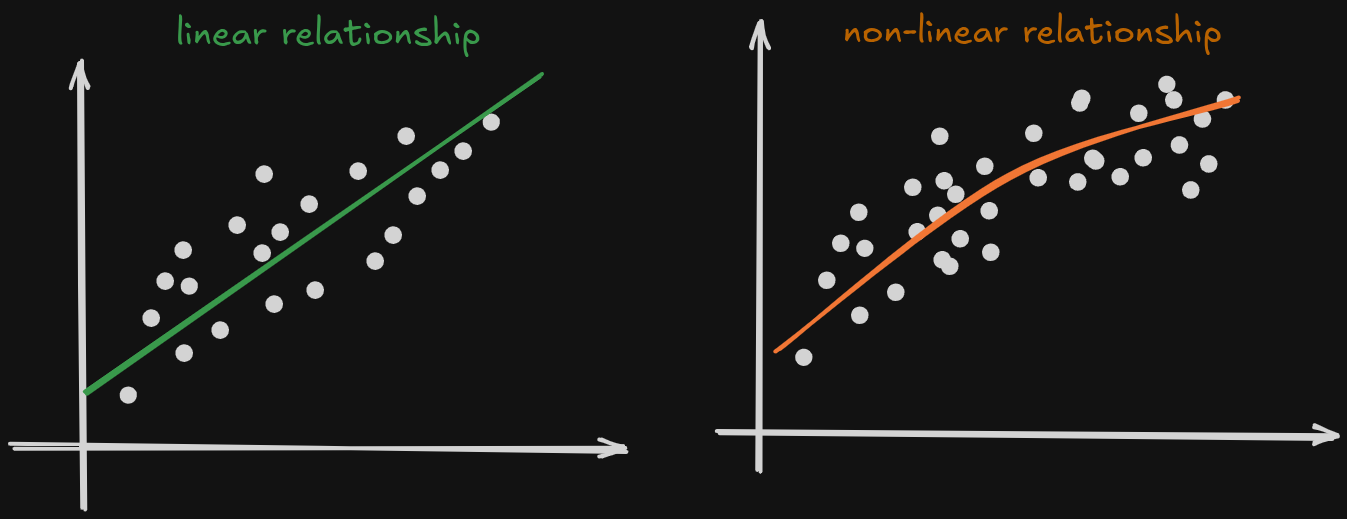

In [37]:
# Extract fitted values and residuals from the fitted model
fitted = model.fittedvalues
residuals = model.resid

##### **Plotting a Residual Plot (Graphical) to check for linearity**

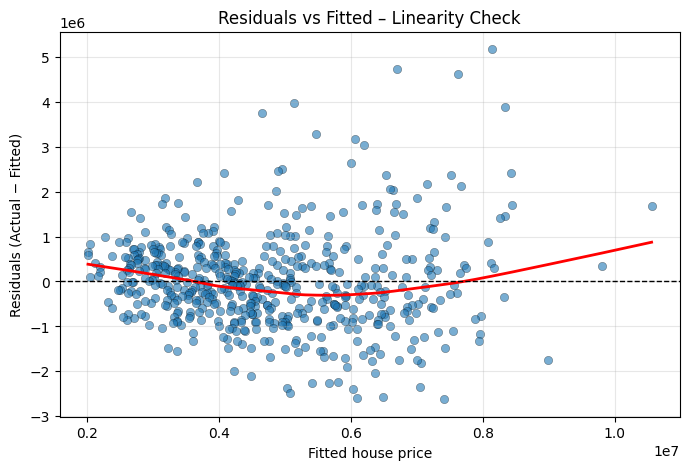

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.6, edgecolors='k', linewidth=0.3)

# LOWESS smooth (robust to outliers)
lowess_fit = lowess(residuals, fitted, frac=0.6, it=3)
plt.plot(lowess_fit[:, 0], lowess_fit[:, 1], color='red', linewidth=2)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Fitted house price')
plt.ylabel('Residuals (Actual − Fitted)')
plt.title('Residuals vs Fitted – Linearity Check')
plt.grid(alpha=0.3)
plt.show()

**Summary:**
Based on the above plot our data in non-linear

##### **Solution to non-linearity:**
- To deal with non-linearity, we can try transforming the variables such as log (X) or √X

##### **remedy: Log-transform**

In [38]:
y_log = np.log(y)
model_log = sm.OLS(y_log, X_sm).fit()
print(model_log.summary())

# Check the new residual plot
fitted_log = model_log.fittedvalues
residuals_log = model_log.resid
# (plot using the same manual code as before)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     94.84
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          4.20e-129
Time:                        15:46:27   Log-Likelihood:                 93.010
No. Observations:                 545   AIC:                            -158.0
Df Residuals:                     531   BIC:                            -97.81
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

##### **Using continous data columns we plot Component‑Residual (CCPR) plots:**

Component-Component plus Residual (CCPR) plots, also known as partial residual plots, are diagnostic tools used in linear regression to assess the relationship between a specific independent variable and the response variable while accounting for the effects of all other variables in the model.

In [40]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')

<Figure size 700x500 with 0 Axes>

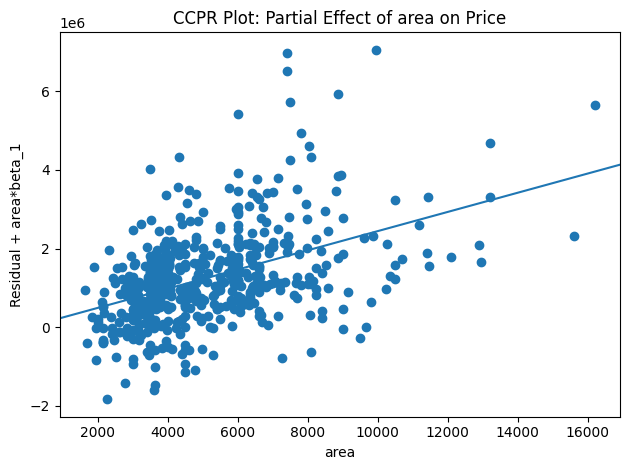

<Figure size 700x500 with 0 Axes>

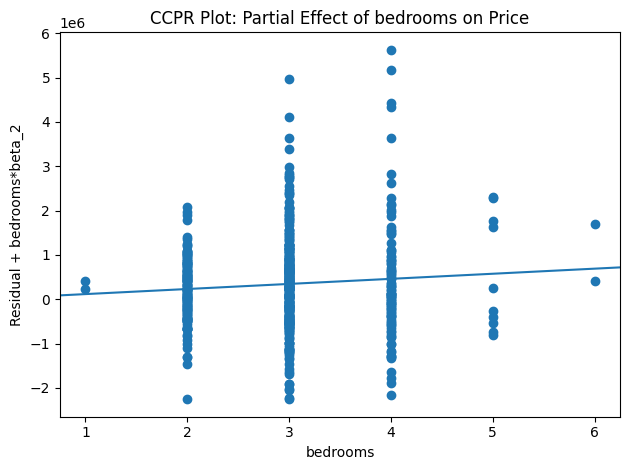

<Figure size 700x500 with 0 Axes>

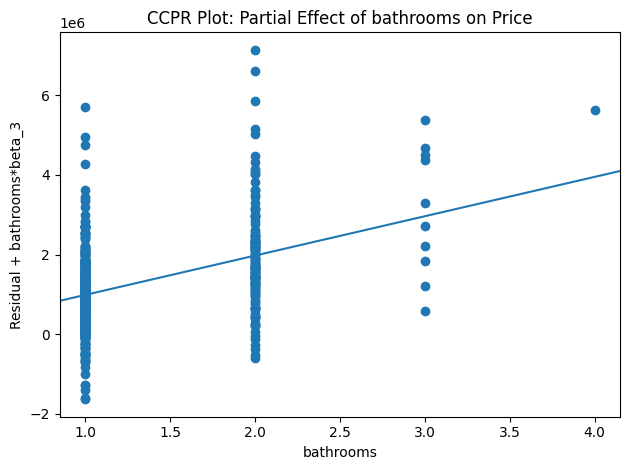

<Figure size 700x500 with 0 Axes>

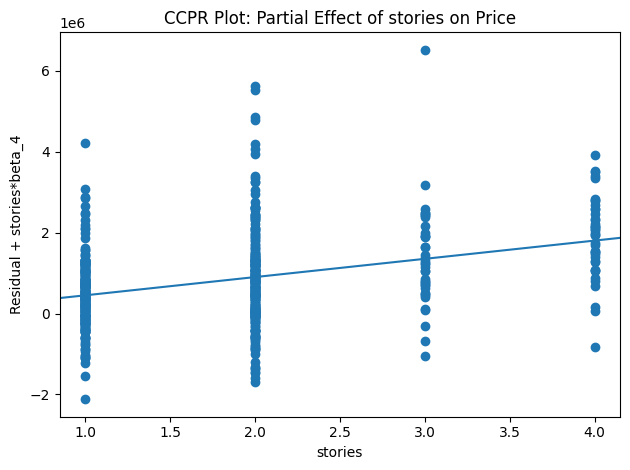

<Figure size 700x500 with 0 Axes>

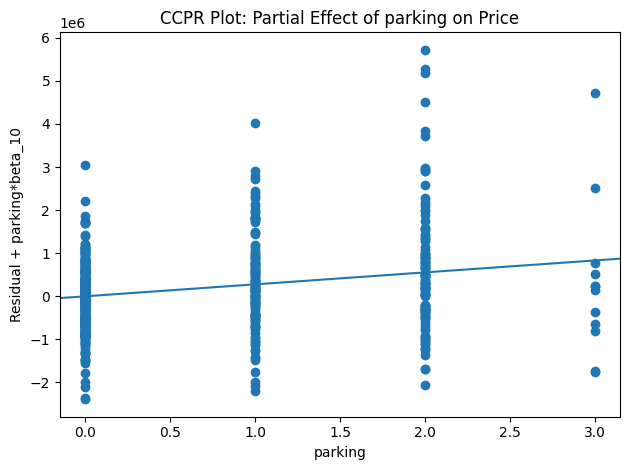

In [39]:
predictors = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for var in predictors:
    fig = plt.figure(figsize=(7, 5))
    plot_ccpr(model, var)
    plt.title(f'CCPR Plot: Partial Effect of {var} on Price')
    plt.tight_layout()
    plt.show()

### **Residual Exections (E(e) = 0 )**

### **Homoscadestacity**

### **Auto-correlation**

### **Normality**

**Supporting Literature**
- [noteBookLM](https://notebooklm.google.com/notebook/39f2acb3-5b72-422f-a98e-016b8e505d81)